In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from datasets import Dataset, DatasetDict
import evaluate
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
import torch
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Load and Prepare Data from Preprocessed File
INPUT_CSV_PATH = 'combined_preprocessed_news.csv' # Load the output from preprocess_data.py

try:
    df = pd.read_csv(INPUT_CSV_PATH)
    print(f"CSV '{INPUT_CSV_PATH}' loaded successfully.")
    print("Columns:", df.columns)

    # --- IMPORTANT: Verify required columns exist ---
    required_cols = ['processed_text', 'encoded_label']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"CSV must contain columns: {required_cols}. Please run preprocess_data.py first.")
    # ---

    # Handle potential missing values just in case (should be minimal after preprocessing)
    df.dropna(subset=['processed_text', 'encoded_label'], inplace=True)
    df['processed_text'] = df['processed_text'].astype(str) # Ensure text is string
    df['encoded_label'] = df['encoded_label'].astype(int)   # Ensure labels are integers

    # Check label distribution
    print("\nLabel Distribution:")
    print(df['encoded_label'].value_counts())
    num_labels = df['encoded_label'].nunique()
    print(f"Number of unique labels: {num_labels}")
    if num_labels != 2:
        print(f"Warning: Expected 2 labels (0 and 1) but found {num_labels}. Check preprocessing script.")
        # Depending on the issue, you might want to exit or filter here.

    # Keep only necessary columns and rename for Hugging Face compatibility
    df = df[['processed_text', 'encoded_label']]
    df.rename(columns={'processed_text': 'text', 'encoded_label': 'label'}, inplace=True)
    print(f"\nData prepared for training. Shape: {df.shape}")


except FileNotFoundError:
    print(f"Error: {INPUT_CSV_PATH} not found. Make sure it was generated by running preprocess_data.py.")
    exit()
except ValueError as ve:
    print(f"Data Error: {ve}")
    exit()
except Exception as e:
    print(f"An unexpected error occurred during data loading: {e}")
    exit()


CSV 'combined_preprocessed_news.csv' loaded successfully.
Columns: Index(['text', 'label', 'subject', 'speaker', 'speaker_job_title',
       'state_info', 'party_affiliation', 'context', 'date', 'source',
       'processed_text', 'encoded_label'],
      dtype='object')

Label Distribution:
encoded_label
1    27649
0    22927
Name: count, dtype: int64
Number of unique labels: 2

Data prepared for training. Shape: (50576, 2)


<ipython-input-2-d294256e2496>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'processed_text': 'text', 'encoded_label': 'label'}, inplace=True)


In [3]:
# Step 3: Split Data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"\nTraining samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

# Convert pandas DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Create a DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

print("\nDatasetDict created:")
print(dataset_dict)


Training samples: 40460
Testing samples: 10116

DatasetDict created:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 40460
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 10116
    })
})


In [4]:
# Step 4: Load Tokenizer and Model
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Check for GPU (T4 or other CUDA-enabled GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Load the model for sequence classification
# num_labels should be 2 based on the preprocessing script (0: FAKE, 1: REAL)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
model.to(device) # Move model to the GPU/CPU


Using device: cuda
GPU Name: Tesla T4


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [5]:
# Step 5: Tokenize Data
def tokenize_function(examples):
    # Truncation=True: Pad or truncate sequences to the model's max input size (512 for DistilBERT)
    # Padding='max_length': Pad sequences to the max length
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=512)

print("\nTokenizing datasets...")
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

# Remove the original text column and any index columns after tokenization
columns_to_remove = ["text"]
if "__index_level_0__" in tokenized_datasets["train"].column_names:
    columns_to_remove.append("__index_level_0__")
tokenized_datasets = tokenized_datasets.remove_columns(columns_to_remove)

tokenized_datasets.set_format("torch") # Ensure tensors are PyTorch tensors

print("\nTokenized datasets prepared:")
print(tokenized_datasets)



Tokenizing datasets...


Map:   0%|          | 0/40460 [00:00<?, ? examples/s]

Map:   0%|          | 0/10116 [00:00<?, ? examples/s]


Tokenized datasets prepared:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 40460
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 10116
    })
})


In [8]:
# Step 6: Define Training Arguments
MODEL_OUTPUT_DIR = './results/distilbert_fake_news'
LOGGING_DIR = './logs/distilbert_fake_news'
SAVED_MODEL_PATH = './saved_model' # Define here for consistency

# Create directories if they don't exist
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)
os.makedirs(SAVED_MODEL_PATH, exist_ok=True)

training_args = TrainingArguments(
    output_dir=MODEL_OUTPUT_DIR,           # Directory to save model checkpoints
    num_train_epochs=3,                   # Total number of training epochs (adjust based on convergence)
    per_device_train_batch_size=16,       # Batch size per device during training (adjust based on GPU memory)
    per_device_eval_batch_size=64,        # Batch size for evaluation
    warmup_steps=200,                     # Number of warmup steps for learning rate scheduler (adjust based on dataset size/batch size)
    weight_decay=0.01,                    # Strength of weight decay
    logging_dir=LOGGING_DIR,              # Directory for storing logs
    logging_steps=50,                     # Log metrics every X updates steps
    save_strategy="epoch",                # Save a model checkpoint at the end of each epoch
    load_best_model_at_end=True,          # Load the best model found during training (based on metric_for_best_model)
    metric_for_best_model="accuracy",     # Use accuracy to determine the best model checkpoint
    greater_is_better=True,               # Higher accuracy is better
    fp16=torch.cuda.is_available(),       # Enable mixed precision training if a GPU is available (speeds up training on T4/V100/A100 etc.)
    report_to="none",                      # Disable external reporting like WandB/TensorBoard unless configured
    # Use 'gradient_accumulation_steps' if you have memory constraints and need larger effective batch sizes
    # The 'evaluation_strategy' argument was introduced in a later version of transformers.
    eval_strategy="epoch"
)

In [13]:
# Step 7: Define Evaluation Metrics Function
# Load metrics using the evaluate library
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")



# Define the label mapping based on the preprocessing script
# IMPORTANT: Ensure this matches the encoding in preprocess_data.py
label_map = {0: "FAKE", 1: "REAL"}
target_names = [label_map[i] for i in sorted(label_map.keys())] # ["FAKE", "REAL"]


def compute_metrics(eval_pred):
    """Computes accuracy, precision, recall, F1 for binary classification."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    # For binary classification, specify pos_label=1 if REAL=1, FAKE=0
    # Or use average='binary' which assumes pos_label=1 by default
    precision = precision_metric.compute(predictions=predictions, references=labels, average="binary")["precision"]
    recall = recall_metric.compute(predictions=predictions, references=labels, average="binary")["recall"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="binary")["f1"]

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [14]:
# Step 8: Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"], # Use the 'test' split for evaluation during training
    compute_metrics=compute_metrics,
    tokenizer=tokenizer, # Pass tokenizer for consistent padding (good practice)
)

<ipython-input-14-a5d06108d410>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [15]:
# Step 9: Train the Model
print("\nStarting model training...")
train_result = trainer.train()
print("Training finished.")

# Log training metrics
metrics = train_result.metrics
trainer.log_metrics("train", metrics)
trainer.save_metrics("train", metrics)


Starting model training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.159300,0.160725,0.911724,0.884941,0.963834,0.922704
2,0.137500,0.178207,0.917754,0.900990,0.954430,0.926941
3,0.114900,0.256311,0.917359,0.910028,0.941953,0.925715


Training finished.
***** train metrics *****
  epoch                    =        3.0
  total_flos               = 14974635GF
  train_loss               =     0.1396
  train_runtime            = 0:28:57.73
  train_samples_per_second =     69.849
  train_steps_per_second   =      4.366



Evaluating the best model on the test set...



--- Evaluation Summary ---
  eval_loss: 0.1782
  eval_accuracy: 0.9178
  eval_precision: 0.9010
  eval_recall: 0.9544
  eval_f1: 0.9269
  eval_runtime: 39.3162
  eval_samples_per_second: 257.2980
  eval_steps_per_second: 4.0440
  epoch: 3.0000

Generating predictions for detailed metrics report...

--- Classification Report ---
              precision    recall  f1-score   support

        FAKE     0.9408    0.8735    0.9059      4586
        REAL     0.9010    0.9544    0.9269      5530

    accuracy                         0.9178     10116
   macro avg     0.9209    0.9140    0.9164     10116
weighted avg     0.9190    0.9178    0.9174     10116


--- Confusion Matrix ---
[[4006  580]
 [ 252 5278]]

Confusion matrix plot saved to ./logs/distilbert_fake_news/confusion_matrix.png


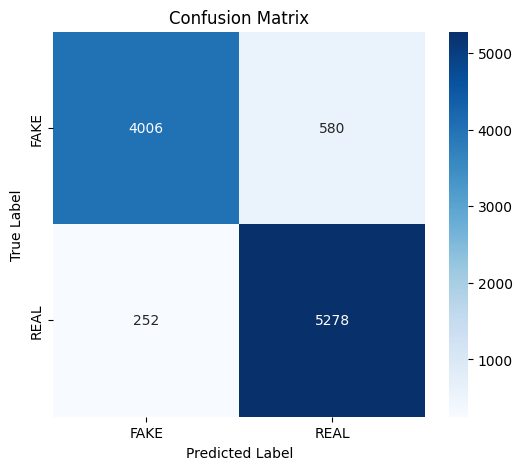

In [16]:
# Step 10: Evaluate the Final Model on the Test Set & Display Comprehensive Metrics
print("\nEvaluating the best model on the test set...")
eval_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"]) # Explicitly evaluate on test set

print("\n--- Evaluation Summary ---")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

# Get predictions for the test set to compute detailed metrics
print("\nGenerating predictions for detailed metrics report...")
predictions_output = trainer.predict(tokenized_datasets["test"])

# Raw predictions (logits) and true labels
y_logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(y_logits, axis=-1)

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Plot Confusion Matrix (Optional but helpful)
try:
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    # Save the plot
    cm_fig_path = os.path.join(LOGGING_DIR, 'confusion_matrix.png')
    plt.savefig(cm_fig_path)
    print(f"\nConfusion matrix plot saved to {cm_fig_path}")
    plt.show()
except ImportError:
    print("\nInstall matplotlib and seaborn (`pip install matplotlib seaborn`) to plot the confusion matrix.")


In [17]:
# Step 11: Save the Fine-Tuned Model, Tokenizer, and Label Map
# The Trainer already saved the best model checkpoint during training due to 'load_best_model_at_end=True'
# We explicitly save the final best model to the desired clean directory './saved_model'
print(f"\nSaving the best model and tokenizer to: {SAVED_MODEL_PATH}")
trainer.save_model(SAVED_MODEL_PATH)
# Tokenizer was likely already saved with the model checkpoint, but save again to ensure it's in the final dir
tokenizer.save_pretrained(SAVED_MODEL_PATH)

# Save the label map (crucial for the app)
label_map_file = os.path.join(SAVED_MODEL_PATH, 'label_map.json')
# Ensure keys are strings for JSON compatibility
label_map_str_keys = {str(k): v for k, v in label_map.items()}
with open(label_map_file, 'w') as f:
    json.dump(label_map_str_keys, f, indent=4) # Use indent for readability
print(f"Label map saved to: {label_map_file}")


Saving the best model and tokenizer to: ./saved_model
Label map saved to: ./saved_model/label_map.json
